In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torchvision.utils import make_grid
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
transform=transforms.ToTensor()

In [5]:
train_data=datasets.MNIST(root='/cnn_data',train=True,download=True,transform=transform)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting /cnn_data\MNIST\raw\train-images-idx3-ubyte.gz to /cnn_data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting /cnn_data\MNIST\raw\train-labels-idx1-ubyte.gz to /cnn_data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting /cnn_data\MNIST\raw\t10k-images-idx3-ubyte.gz to /cnn_data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting /cnn_data\MNIST\raw\t10k-labels-idx1-ubyte.gz to /cnn_data\MNIST\raw



In [6]:
test_data=datasets.MNIST(root='/cnn_data',train=False,download=True,transform=transform)

In [7]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [8]:
pwd

'C:\\Users\\HP'

In [9]:
ls

 Volume in drive C has no label.
 Volume Serial Number is A887-A3D8

 Directory of C:\Users\HP

10/05/2026  04:36 PM    <DIR>          .
28/12/2025  07:01 PM    <DIR>          ..
01/05/2026  06:38 PM    <DIR>          .copilot
10/05/2026  04:28 PM    <DIR>          .ipynb_checkpoints
29/04/2026  10:26 AM    <DIR>          .ipython
01/05/2026  11:50 AM    <DIR>          .jupyter
01/05/2026  11:51 AM    <DIR>          .keras
09/05/2026  07:46 PM    <DIR>          .matplotlib
29/04/2026  10:42 AM    <DIR>          .ms-ad
01/05/2026  06:38 PM    <DIR>          .vscode
01/05/2026  06:38 PM    <DIR>          .vscode-shared
03/03/2026  03:49 PM             8,139 banglore_home_prices_model.pickle
03/03/2026  03:33 PM           744,720 bhp.csv
07/03/2026  02:43 PM               279 class_dictionary.json
03/03/2026  03:49 PM             3,994 columns.json
28/12/2025  07:08 PM    <DIR>          Contacts
16/04/2026  12:42 PM           196,300 Customer Churn Prediction using ANN.ipynb
18/04/2026  0

In [10]:
cd ../

C:\Users


In [11]:
pwd

'C:\\Users'

In [12]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [13]:
train_loader=DataLoader(train_data,batch_size=10,shuffle=True)
test_loader=DataLoader(test_data,batch_size=10,shuffle=True)

In [14]:
conv1=nn.Conv2d(1,6,3,1)
conv2=nn.Conv2d(6,16,3,1)

In [15]:
for i,(X_train,y_train) in enumerate(train_data):
    break

In [17]:
X_train.shape

torch.Size([1, 28, 28])

In [18]:
x=X_train.view(1,1,28,28)

In [19]:
x=F.relu(conv1(x))

In [20]:
x.shape

torch.Size([1, 6, 26, 26])

In [21]:
x=F.max_pool2d(x,2,2)

In [22]:
x.shape

torch.Size([1, 6, 13, 13])

In [23]:
x=F.relu(conv2(x))

In [24]:
x.shape

torch.Size([1, 16, 11, 11])

In [25]:
x=F.max_pool2d(x,2,2)

In [27]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(1,6,3,1)
        self.conv2=nn.Conv2d(6,16,3,1)
        self.fc1=nn.Linear(5*5*16,120)
        self.fc2=nn.Linear(120,84)
        self.fc3=nn.Linear(84,10)

    def forward(self,X):
        X=F.relu(self.conv1(X))
        X=F.max_pool2d(X,2,2)
        X=F.relu(self.conv2(X))
        X=F.max_pool2d(X,2,2)
        X=X.view(-1,16*5*5)
        X=F.relu(self.fc1(X))
        X=F.relu(self.fc2(X))
        X=self.fc3(X)

        return F.log_softmax(X,dim=1)     

In [28]:
torch.manual_seed(41)
model=ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [29]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [34]:
import time

start_time = time.time()

epochs = 5

train_losses = []
test_losses = []

train_correct = []
test_correct = []

for i in range(epochs):

    trn_corr = 0
    tst_corr = 0

    # TRAINING
    for b, (X_train, y_train) in enumerate(train_loader):

        b += 1

        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()

        trn_corr += batch_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b % 600 == 0:
            print(f'Epoch: {i} Batch: {b} Loss: {loss.item()}')

    train_losses.append(loss)
    train_correct.append(trn_corr)

    # TESTING
    with torch.no_grad():

        for b, (X_test, y_test) in enumerate(test_loader):

            y_val = model(X_test)

            predicted = torch.max(y_val.data, 1)[1]

            tst_corr += (predicted == y_test).sum()

    loss = criterion(y_val, y_test)

    test_losses.append(loss)
    test_correct.append(tst_corr)

current_time = time.time()

total = current_time - start_time

print(f'Training took: {total/60} minutes')

Epoch: 0 Batch: 600 Loss: 0.15999338030815125
Epoch: 0 Batch: 1200 Loss: 0.18245236575603485
Epoch: 0 Batch: 1800 Loss: 0.5544059872627258
Epoch: 0 Batch: 2400 Loss: 0.18248456716537476
Epoch: 0 Batch: 3000 Loss: 0.008711984381079674
Epoch: 0 Batch: 3600 Loss: 0.30476781725883484
Epoch: 0 Batch: 4200 Loss: 0.005024028941988945
Epoch: 0 Batch: 4800 Loss: 0.0016702963039278984
Epoch: 0 Batch: 5400 Loss: 0.0593353807926178
Epoch: 0 Batch: 6000 Loss: 0.0005705910734832287
Epoch: 1 Batch: 600 Loss: 0.037865426391363144
Epoch: 1 Batch: 1200 Loss: 0.004398747812956572
Epoch: 1 Batch: 1800 Loss: 0.002226050477474928
Epoch: 1 Batch: 2400 Loss: 0.0030549883376806974
Epoch: 1 Batch: 3000 Loss: 8.90264127519913e-05
Epoch: 1 Batch: 3600 Loss: 0.010861423797905445
Epoch: 1 Batch: 4200 Loss: 0.0006017424166202545
Epoch: 1 Batch: 4800 Loss: 0.004546769428998232
Epoch: 1 Batch: 5400 Loss: 0.00040850182995200157
Epoch: 1 Batch: 6000 Loss: 0.000375606759916991
Epoch: 2 Batch: 600 Loss: 0.0317754298448562

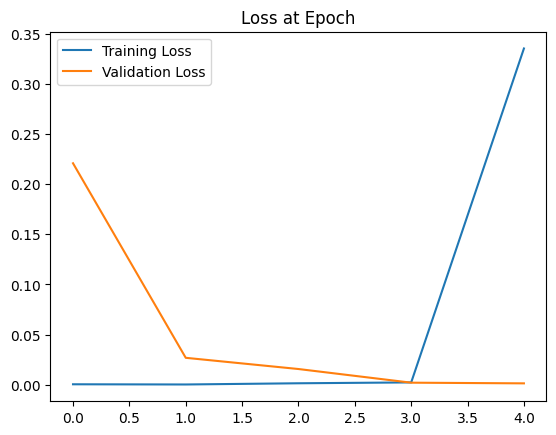

In [35]:
train_losses=[tl.item() for tl in train_losses]
plt.plot(train_losses,label="Training Loss")
plt.plot(test_losses,label="Validation Loss")
plt.title("Loss at Epoch")
plt.legend()

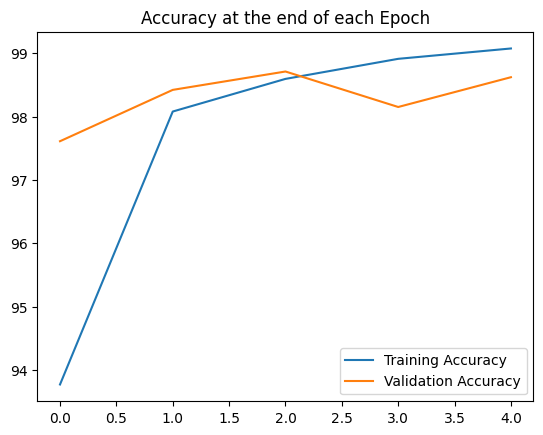

In [37]:
plt.plot([t/600 for t in train_correct],label="Training Accuracy")
plt.plot([t/100 for t in test_correct],label="Validation Accuracy")
plt.title("Accuracy at the end of each Epoch")
plt.legend()

In [38]:
test_load_everything=DataLoader(test_data,batch_size=10000,shuffle=False)

In [39]:
with torch.no_grad():
    correct=0
    for X_test,y_test in test_load_everything:
        y_val=model(X_test)
        predicted=torch.max(y_val,1)[1]
        correct+=(predicted==y_test).sum()

In [40]:
correct.item()/len(test_data)*100

98.61999999999999

In [41]:
test_data[4143]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [42]:
test_data[4143][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [43]:
test_data[4143][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

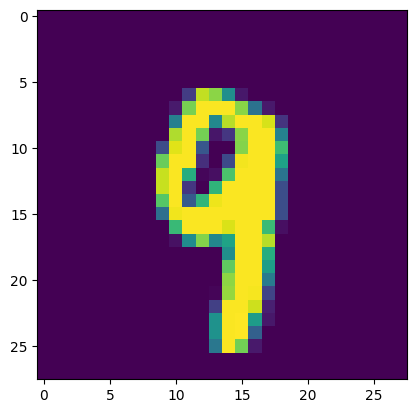

In [44]:
plt.imshow(test_data[4143][0].reshape(28,28))

In [45]:
model.eval()
with torch.no_grad():
    new_prediction=model(test_data[4143][0].view(1,1,28,28))

In [46]:
new_prediction

tensor([[-2.2088e+01, -1.9329e+01, -2.0584e+01, -1.6185e+01, -1.0995e+01,
         -1.7272e+01, -3.2784e+01, -9.3844e+00, -1.6453e+01, -1.0108e-04]])

In [47]:
new_prediction.argmax()

tensor(9)